In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the spotify cleaned data
df = pd.read_csv('spotify_cleaned.csv')

In [6]:
## Dataset Overview
# Display first few rows
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

# Show data types
print("\n" + "="*60)
print("Data Types:")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("Column Information by Type:")
print("="*60)

# Categorize columns by type
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Boolean columns ({len(bool_cols)}): {bool_cols}")
if datetime_cols:
    print(f"DateTime columns ({len(datetime_cols)}): {datetime_cols}")

Dataset shape: (20493, 25)

First few rows:
          Artist                                          Track  \
0     The Weeknd                                Blinding Lights   
1     Ed Sheeran                                   Shape of You   
2  Lewis Capaldi                              Someone You Loved   
3    Post Malone                     rockstar (feat. 21 Savage)   
4       Swae Lee  Sunflower - Spider-Man: Into the Spider-Verse   

                                     Album Album_type  Danceability  Energy  \
0                              After Hours      album         0.514   0.730   
1                               ÷ (Deluxe)      album         0.825   0.652   
2  Divinely Uninspired To A Hellish Extent      album         0.501   0.405   
3                     beerbongs & bentleys      album         0.585   0.520   
4                     Hollywood's Bleeding      album         0.755   0.522   

   Loudness  Speechiness  Acousticness  Instrumentalness  ...  \
0    -5.934  


Correlation Matrix:
                      Danceability    Energy  Loudness  Speechiness  \
Danceability              1.000000  0.231560  0.349805     0.208252   
Energy                    0.231560  1.000000  0.743889     0.063570   
Loudness                  0.349805  0.743889  1.000000     0.032052   
Speechiness               0.208252  0.063570  0.032052     1.000000   
Acousticness             -0.278129 -0.657568 -0.547307    -0.076592   
Instrumentalness         -0.311891 -0.305344 -0.541523    -0.108665   
Liveness                 -0.083128  0.174383  0.088376     0.086244   
Valence                   0.461996  0.385719  0.308258     0.057088   
Tempo                    -0.077754  0.150917  0.136221     0.035434   
Duration_min             -0.090850  0.021927  0.010800    -0.051019   
Views                     0.087864  0.065822  0.118001    -0.014968   
Likes                     0.097989  0.061339  0.123799     0.005031   
Comments                  0.043461  0.043914  0.059065  

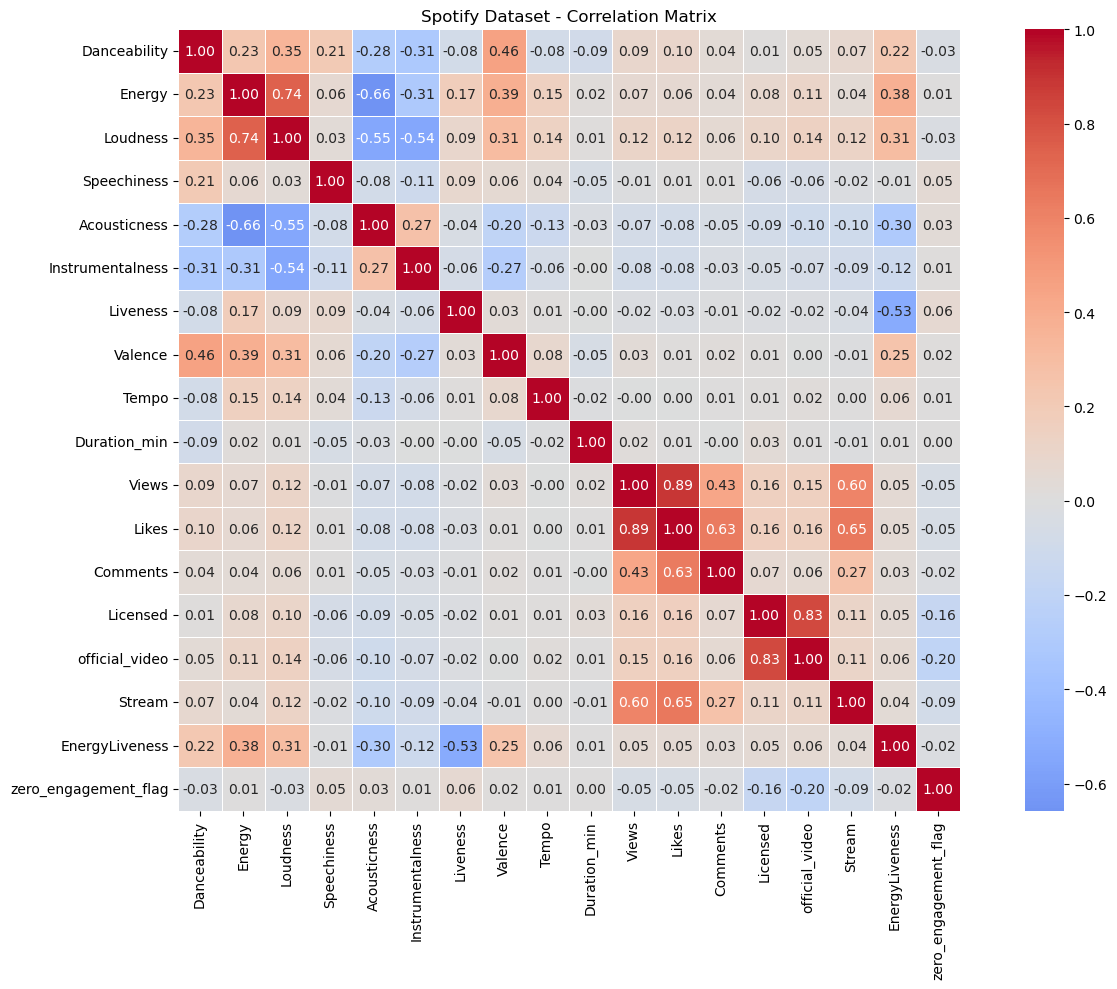

In [7]:
## 1) Correlation Matrix 
# Create correlation matrix (only for numeric columns)
correlation_matrix = df.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Spotify Dataset - Correlation Matrix')
plt.tight_layout()
plt.show()

In [8]:
## 2) VIF Analysis - Multicollinearity Testing for Feature Selection
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("VARIANCE INFLATION FACTOR (VIF) ANALYSIS")
print("="*80)
print("VIF measures how much the variance of a coefficient is inflated due to multicollinearity")
print("VIF > 10: High multicollinearity (drop feature)")
print("VIF 5-10: Moderate multicollinearity (consider dropping)")
print("VIF < 5: Acceptable level\n")

# Get numeric columns
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()

# Standardize features for VIF calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols_all])
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols_all)

# Calculate VIF for all features
print("INITIAL VIF ANALYSIS (All Features)")
print("-" * 80)
vif_results = pd.DataFrame()
vif_results['Feature'] = numeric_cols_all
vif_results['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]
vif_results = vif_results.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_results.to_string(index=False))

# Categorize features by VIF level
high_vif = vif_results[vif_results['VIF'] > 10]['Feature'].tolist()
moderate_vif = vif_results[(vif_results['VIF'] >= 5) & (vif_results['VIF'] <= 10)]['Feature'].tolist()
acceptable_vif = vif_results[vif_results['VIF'] < 5]['Feature'].tolist()

print(f"\n✓ Acceptable VIF (< 5): {len(acceptable_vif)} features")
print(f"   {acceptable_vif[:5]}{'...' if len(acceptable_vif) > 5 else ''}")

if moderate_vif:
    print(f"\n⚠️  Moderate multicollinearity (5-10): {len(moderate_vif)} features")
    print(f"   {moderate_vif}")

if high_vif:
    print(f"\n❌ High multicollinearity (> 10): {len(high_vif)} features")
    print(f"   {high_vif}")

# Iterative VIF reduction - drop highest VIF features one by one
print("\n" + "="*80)
print("ITERATIVE VIF REDUCTION")
print("="*80)
print("Dropping features with VIF > 10 iteratively until all remaining VIF < 10\n")

X_refined = X_scaled_df.copy()
dropped_features = []
iteration = 0

while True:
    iteration += 1
    vif_current = pd.DataFrame()
    vif_current['Feature'] = X_refined.columns
    vif_current['VIF'] = [variance_inflation_factor(X_refined.values, i) for i in range(X_refined.shape[1])]
    vif_current = vif_current.sort_values('VIF', ascending=False)
    
    max_vif = vif_current['VIF'].max()
    
    if max_vif > 10:
        feature_to_drop = vif_current.iloc[0]['Feature']
        drop_vif = vif_current.iloc[0]['VIF']
        print(f"Iteration {iteration}: Dropping '{feature_to_drop}' (VIF = {drop_vif:.2f})")
        X_refined = X_refined.drop(columns=[feature_to_drop])
        dropped_features.append(feature_to_drop)
    else:
        print(f"\n✓ Completed after {iteration-1} iterations")
        break

# Final VIF results
print("\n" + "="*80)
print("FINAL VIF ANALYSIS (Refined Features)")
print("="*80)
vif_final = pd.DataFrame()
vif_final['Feature'] = X_refined.columns
vif_final['VIF'] = [variance_inflation_factor(X_refined.values, i) for i in range(X_refined.shape[1])]
vif_final = vif_final.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_final.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY & RECOMMENDATIONS")
print("="*80)
print(f"Original features: {len(numeric_cols_all)}")
print(f"Refined features: {len(X_refined.columns)}")
print(f"Features dropped: {len(dropped_features)}")
if dropped_features:
    print(f"  → {dropped_features}")

print(f"\nMax VIF in original data: {vif_results['VIF'].max():.2f}")
print(f"Max VIF in refined data: {vif_final['VIF'].max():.2f}")
print(f"\nSuggested features for A/B testing (low multicollinearity):")
print(f"  {list(X_refined.columns)}")

# Create refined dataset for A/B testing
df_refined = df[list(X_refined.columns) + [col for col in df.columns if col not in numeric_cols_all]]
print(f"\nRefined dataset shape: {df_refined.shape}")
print(f"  Original: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Refined:  {df_refined.shape[0]} rows, {df_refined.shape[1]} columns")

VARIANCE INFLATION FACTOR (VIF) ANALYSIS
VIF measures how much the variance of a coefficient is inflated due to multicollinearity
VIF > 10: High multicollinearity (drop feature)
VIF 5-10: Moderate multicollinearity (consider dropping)
VIF < 5: Acceptable level

INITIAL VIF ANALYSIS (All Features)
--------------------------------------------------------------------------------
         Feature      VIF
           Likes 9.201996
           Views 5.745320
          Energy 3.890890
        Loudness 3.210542
  EnergyLiveness 2.078618
        Comments 2.064848
    Acousticness 1.916775
          Stream 1.868203
        Liveness 1.835528
    Danceability 1.616947
         Valence 1.549235
Instrumentalness 1.543324
     Speechiness 1.087120
           Tempo 1.063708
    Duration_min 1.017457

✓ Acceptable VIF (< 5): 13 features
   ['Energy', 'Loudness', 'EnergyLiveness', 'Comments', 'Acousticness']...

⚠️  Moderate multicollinearity (5-10): 2 features
   ['Likes', 'Views']

ITERATIVE VIF REDUC

INTERACTION TERMS ANALYSIS (Refined Features)
Testing which interaction terms are significant for A/B testing

Correlation Matrix (Refined Features):
                  Danceability  Energy  Loudness  Speechiness  Acousticness  \
Danceability             1.000   0.232     0.350        0.208        -0.278   
Energy                   0.232   1.000     0.744        0.064        -0.658   
Loudness                 0.350   0.744     1.000        0.032        -0.547   
Speechiness              0.208   0.064     0.032        1.000        -0.077   
Acousticness            -0.278  -0.658    -0.547       -0.077         1.000   
Instrumentalness        -0.312  -0.305    -0.542       -0.109         0.273   
Liveness                -0.083   0.174     0.088        0.086        -0.040   
Valence                  0.462   0.386     0.308        0.057        -0.197   
Tempo                   -0.078   0.151     0.136        0.035        -0.127   
Duration_min            -0.091   0.022     0.011       -0.05

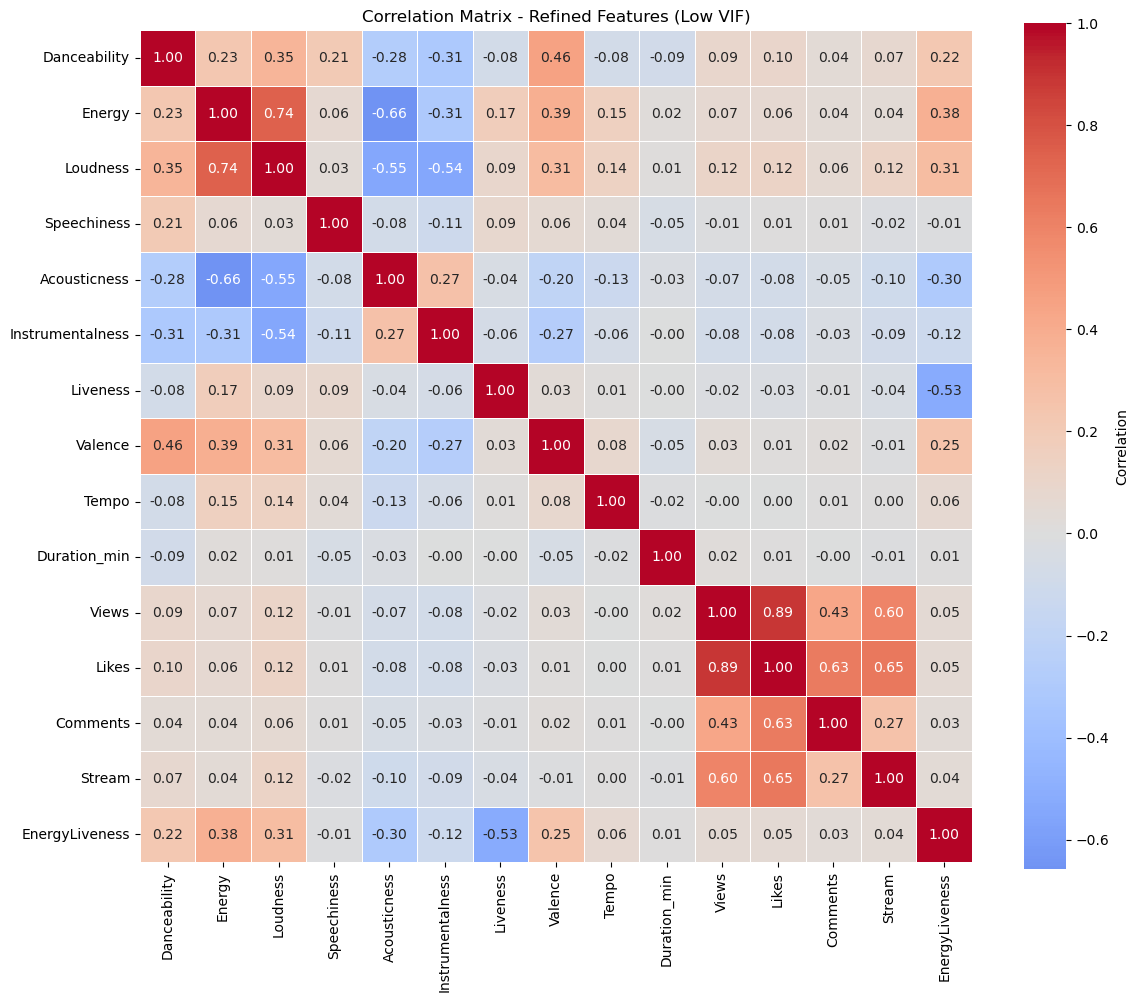


RECOMMENDED METRICS FOR A/B TESTING
Features (low multicollinearity, VIF < 10):
  1. Danceability         (VIF:   1.62)
  2. Energy               (VIF:   3.89)
  3. Loudness             (VIF:   3.21)
  4. Speechiness          (VIF:   1.09)
  5. Acousticness         (VIF:   1.92)
  6. Instrumentalness     (VIF:   1.54)
  7. Liveness             (VIF:   1.84)
  8. Valence              (VIF:   1.55)
  9. Tempo                (VIF:   1.06)
  10. Duration_min         (VIF:   1.02)
  11. Views                (VIF:   5.75)
  12. Likes                (VIF:   9.20)
  13. Comments             (VIF:   2.06)
  14. Stream               (VIF:   1.87)
  15. EnergyLiveness       (VIF:   2.08)


In [9]:
## 2.5) Interaction Terms Analysis on Refined Features
print("="*80)
print("INTERACTION TERMS ANALYSIS (Refined Features)")
print("="*80)
print("Testing which interaction terms are significant for A/B testing\n")

# Get refined features
refined_features = list(X_refined.columns)

# Show correlation matrix for refined features
correlation_refined = df_refined[refined_features].corr()

print("Correlation Matrix (Refined Features):")
print(correlation_refined.round(3))

# Find high correlations (excluding diagonal)
print("\n" + "-"*80)
print("High Correlations (|r| > 0.7) Among Refined Features:")
print("-"*80)

high_corr_pairs = []
for i in range(len(correlation_refined.columns)):
    for j in range(i+1, len(correlation_refined.columns)):
        corr_val = correlation_refined.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = correlation_refined.columns[i]
            feat2 = correlation_refined.columns[j]
            high_corr_pairs.append((feat1, feat2, corr_val))
            print(f"  {feat1} ↔ {feat2}: {corr_val:.3f}")

if not high_corr_pairs:
    print("  ✓ No high correlations (>0.7) found among refined features")

# Visualize correlation matrix for refined features
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_refined, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Refined Features (Low VIF)')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("RECOMMENDED METRICS FOR A/B TESTING")
print("="*80)
print(f"Features (low multicollinearity, VIF < 10):")
for i, feat in enumerate(refined_features, 1):
    vif_val = vif_final[vif_final['Feature'] == feat]['VIF'].values[0]
    print(f"  {i}. {feat:20s} (VIF: {vif_val:6.2f})")

In [10]:
## 3) Stricter VIF Reduction (VIF > 3)
print("="*80)
print("STRICTER VIF REDUCTION (VIF > 3)")
print("="*80)
print("Dropping features with VIF > 3 for even lower multicollinearity\n")

X_strict = X_refined.copy()
dropped_strict = []
iteration = 0

while True:
    iteration += 1
    vif_current = pd.DataFrame()
    vif_current['Feature'] = X_strict.columns
    vif_current['VIF'] = [variance_inflation_factor(X_strict.values, i) for i in range(X_strict.shape[1])]
    vif_current = vif_current.sort_values('VIF', ascending=False)
    
    max_vif = vif_current['VIF'].max()
    
    if max_vif > 3:
        feature_to_drop = vif_current.iloc[0]['Feature']
        drop_vif = vif_current.iloc[0]['VIF']
        print(f"Iteration {iteration}: Dropping '{feature_to_drop}' (VIF = {drop_vif:.2f})")
        X_strict = X_strict.drop(columns=[feature_to_drop])
        dropped_strict.append(feature_to_drop)
    else:
        print(f"\n✓ Completed after {iteration-1} iterations")
        break

# Final VIF results for strict
print("\n" + "="*80)
print("FINAL VIF ANALYSIS (Strict Features)")
print("="*80)
vif_strict = pd.DataFrame()
vif_strict['Feature'] = X_strict.columns
vif_strict['VIF'] = [variance_inflation_factor(X_strict.values, i) for i in range(X_strict.shape[1])]
vif_strict = vif_strict.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_strict.to_string(index=False))

print("\n" + "="*80)
print("SUMMARY & RECOMMENDATIONS (Strict)")
print("="*80)
print(f"Previous refined features: {len(X_refined.columns)}")
print(f"Strict features: {len(X_strict.columns)}")
print(f"Additional features dropped: {len(dropped_strict)}")
if dropped_strict:
    print(f"  → {dropped_strict}")

print(f"\nMax VIF in strict data: {vif_strict['VIF'].max():.2f}")
print(f"\nSuggested features for A/B testing (very low multicollinearity):")
print(f"  {list(X_strict.columns)}")

# Create strict dataset
df_strict = df[list(X_strict.columns) + [col for col in df.columns if col not in numeric_cols_all]]
print(f"\nStrict dataset shape: {df_strict.shape}")
print(f"  Original: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"  Strict:  {df_strict.shape[0]} rows, {df_strict.shape[1]} columns")

STRICTER VIF REDUCTION (VIF > 3)
Dropping features with VIF > 3 for even lower multicollinearity

Iteration 1: Dropping 'Likes' (VIF = 9.20)
Iteration 2: Dropping 'Energy' (VIF = 3.89)

✓ Completed after 2 iterations

FINAL VIF ANALYSIS (Strict Features)
         Feature      VIF
        Loudness 2.107518
  EnergyLiveness 1.840874
           Views 1.788079
        Liveness 1.626143
          Stream 1.582193
    Danceability 1.550696
    Acousticness 1.527615
Instrumentalness 1.485543
         Valence 1.418266
        Comments 1.229896
     Speechiness 1.080643
           Tempo 1.063569
    Duration_min 1.017100

SUMMARY & RECOMMENDATIONS (Strict)
Previous refined features: 15
Strict features: 13
Additional features dropped: 2
  → ['Likes', 'Energy']

Max VIF in strict data: 2.11

Suggested features for A/B testing (very low multicollinearity):
  ['Danceability', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_min', 'Views', 'Comm

CORRELATION ANALYSIS (Strict Features)
Checking correlations among features with VIF ≤ 3

Correlation Matrix (Strict Features):
                  Danceability  Loudness  Speechiness  Acousticness  \
Danceability             1.000     0.350        0.208        -0.278   
Loudness                 0.350     1.000        0.032        -0.547   
Speechiness              0.208     0.032        1.000        -0.077   
Acousticness            -0.278    -0.547       -0.077         1.000   
Instrumentalness        -0.312    -0.542       -0.109         0.273   
Liveness                -0.083     0.088        0.086        -0.040   
Valence                  0.462     0.308        0.057        -0.197   
Tempo                   -0.078     0.136        0.035        -0.127   
Duration_min            -0.091     0.011       -0.051        -0.028   
Views                    0.088     0.118       -0.015        -0.073   
Comments                 0.043     0.059        0.007        -0.053   
Stream              

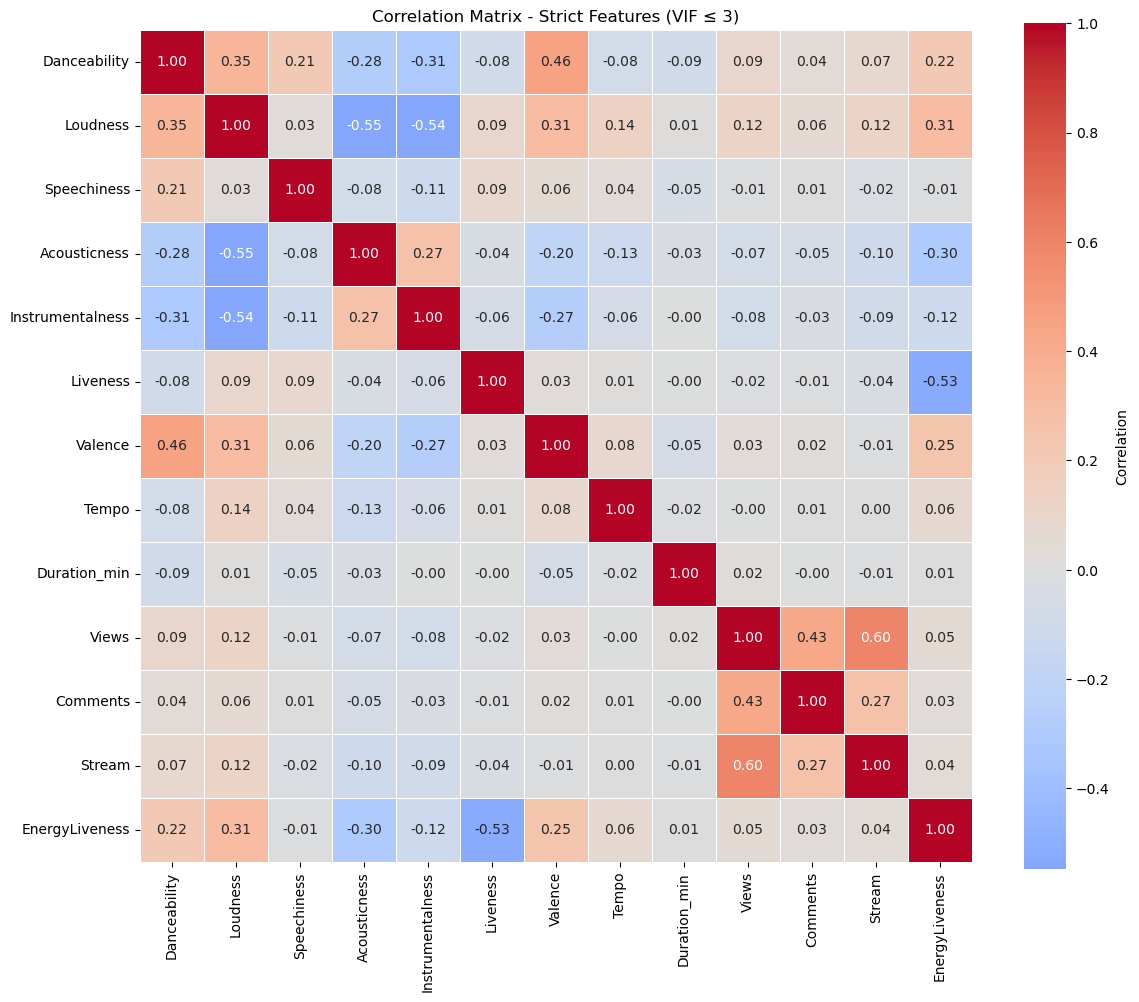


FINAL RECOMMENDED METRICS FOR A/B TESTING
Features (very low multicollinearity, VIF ≤ 3):
  1. Danceability         (VIF:   1.55)
  2. Loudness             (VIF:   2.11)
  3. Speechiness          (VIF:   1.08)
  4. Acousticness         (VIF:   1.53)
  5. Instrumentalness     (VIF:   1.49)
  6. Liveness             (VIF:   1.63)
  7. Valence              (VIF:   1.42)
  8. Tempo                (VIF:   1.06)
  9. Duration_min         (VIF:   1.02)
  10. Views                (VIF:   1.79)
  11. Comments             (VIF:   1.23)
  12. Stream               (VIF:   1.58)
  13. EnergyLiveness       (VIF:   1.84)


In [11]:
## 3.5) Correlation Analysis on Strict Features
print("="*80)
print("CORRELATION ANALYSIS (Strict Features)")
print("="*80)
print("Checking correlations among features with VIF ≤ 3\n")

# Get strict features
strict_features = list(X_strict.columns)

# Show correlation matrix for strict features
correlation_strict = df_strict[strict_features].corr()

print("Correlation Matrix (Strict Features):")
print(correlation_strict.round(3))

# Find high correlations (excluding diagonal)
print("\n" + "-"*80)
print("High Correlations (|r| > 0.7) Among Strict Features:")
print("-"*80)

high_corr_pairs_strict = []
for i in range(len(correlation_strict.columns)):
    for j in range(i+1, len(correlation_strict.columns)):
        corr_val = correlation_strict.iloc[i, j]
        if abs(corr_val) > 0.7:
            feat1 = correlation_strict.columns[i]
            feat2 = correlation_strict.columns[j]
            high_corr_pairs_strict.append((feat1, feat2, corr_val))
            print(f"  {feat1} ↔ {feat2}: {corr_val:.3f}")

if not high_corr_pairs_strict:
    print("  ✓ No high correlations (>0.7) found among strict features")

# Visualize correlation matrix for strict features
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_strict, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix - Strict Features (VIF ≤ 3)')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("FINAL RECOMMENDED METRICS FOR A/B TESTING")
print("="*80)
print(f"Features (very low multicollinearity, VIF ≤ 3):")
for i, feat in enumerate(strict_features, 1):
    vif_val = vif_strict[vif_strict['Feature'] == feat]['VIF'].values[0]
    print(f"  {i}. {feat:20s} (VIF: {vif_val:6.2f})")